## Full Assemble Them All Knowledge gap Notebook

## Test Question 1: Next Step Prediction

**Question**: Given the first few steps of an assembly sequence, predict the most likely next assembly step.

In [5]:
def create_next_step_prompt():
    prompt = f"""You are an expert in industrial assembly planning.

Here is the beginning of an assembly sequence:
Assembly Type: joint_assembly
Number of parts: 2

The first few steps are: [Planning and Design Review / Component Preparation, Surface Cleaning and Lubrication (if applicable), Alignment and Positioning of Components, Initial Fastener Placement or Partial Assembly]

What is the most likely next assembly step?

Explain your reasoning step by step, then give the final prediction inside [[ANSWER]].
"""
    return prompt

print(create_next_step_prompt())

You are an expert in industrial assembly planning.

Here is the beginning of an assembly sequence:
Assembly Type: joint_assembly
Number of parts: 2

The first few steps are: [Planning and Design Review / Component Preparation, Surface Cleaning and Lubrication (if applicable), Alignment and Positioning of Components, Initial Fastener Placement or Partial Assembly]

What is the most likely next assembly step?

Explain your reasoning step by step, then give the final prediction inside [[ANSWER]].



Record LLM Response

In [8]:
# Question 1: Next Step Prediction
llm_response_q1 = """
1. Current sequence position

You already have:

Planning & preparation ✔️
Surface prep (cleaning/lubrication) ✔️
Alignment and positioning ✔️
Initial fastener placement / partial engagement ✔️

At this point:

Parts are aligned
Fastener is engaged (threads started or components partially joined)
2. What logically comes next

Once a fastener is placed and partially engaged, the next critical step is:

➡️ Apply controlled tightening

This transitions the assembly from:

Loose/pre-assembled
→ to
Fully secured and load-bearing
3. Why not other steps?
You wouldn’t re-align → already done
You wouldn’t inspect yet → not fully secured
You wouldn’t add new components → this is a 2-part assembly
4. Engineering reasoning

Best practice sequence:

Start threads / partial engagement (to avoid cross-threading)
Then progressively tighten to final torque specification

This ensures:

Proper seating
Even load distribution
Avoidance of thread damage
Final Prediction

[[Final tightening to specified torque]]
"""

q1_label_correct = True      
q1_reasoning_quality = "Fair"   # It correctly identified procedural issue but reasoning was somewhat generic

## Test Question 2: Part Feasibility

**Question**: Given two parts and a proposed mating action, determine if it is physically feasible.

In [6]:
def create_feasibility_prompt():
    prompt = f"""You are an expert in mechanical assembly and physics-based reasoning.

Consider this assembly:
- Assembly Type: joint_assembly
- Number of parts: 2
- Mesh files available: 2

Is it physically feasible to mate part A into part B using a simple insertion motion?

Explain your reasoning (considering geometry, degrees of freedom, collisions, etc.), then answer with:
- Feasible
- Not Feasible
- Uncertain

Final answer inside [[ANSWER]].
"""
    return prompt

print(create_feasibility_prompt())

You are an expert in mechanical assembly and physics-based reasoning.

Consider this assembly:
- Assembly Type: joint_assembly
- Number of parts: 2
- Mesh files available: 2

Is it physically feasible to mate part A into part B using a simple insertion motion?

Explain your reasoning (considering geometry, degrees of freedom, collisions, etc.), then answer with:
- Feasible
- Not Feasible
- Uncertain

Final answer inside [[ANSWER]].



Record LLM Response

In [9]:
# Question 2: Feasibility Check
llm_response_q2 = """
1. Requirements for simple insertion
For a motion to be a valid simple insertion, the geometry must allow:
- Single dominant degree of freedom (1 DOF) → straight-line translation
- A clear insertion axis (e.g., peg-in-hole, shaft-in-bore)
- No geometric undercuts or interlocking features that require rotation or deformation
- Collision-free path from start to final seated position

2. What we know (and don’t know)
- Assembly type: joint_assembly → suggests intended mating
- Parts: 2 → simple pair, but geometry unknown
- Mesh files exist, but no geometric details are provided

Missing critical info:
- Shape (cylindrical? keyed? threaded? snap-fit?)
- Presence of:
    - Threads → require rotation
    - Hooks/snap features → require deformation
    - Complex interlocks → require multi-axis motion

3. Physical reasoning under uncertainty
Without geometry:
- It could be feasible (e.g., shaft into hole)
- It could be infeasible (e.g., threaded fastener, bayonet mount, snap-fit)

There’s no basis to confirm:
- A valid insertion axis
- Absence of collisions
- DOF constraints

4. Engineering judgment
In assembly planning, when:
- Geometry is unknown
- Constraints are undefined
→ The correct classification is indeterminate, not assumed.
Final Answer
[[Uncertain]]
"""

q2_label_correct = True       # "Uncertain" is reasonable given lack of geometry
q2_reasoning_quality = "Fair"

## Test Question 3: Disassembly Strategy

## Test Question 3: Disassembly Strategy

**Question**: Given a fully assembled product, suggest a valid disassembly sequence that avoids collisions or damage.

In [26]:
def create_disassembly_prompt(sample_idx=0):
    sample = data["samples"][sample_idx]
    prompt = f"""You are an expert in assembly and disassembly planning.

For this assembly:
- Type: {sample['labels'].get('assembly_type')}
- Number of parts: {sample['labels'].get('num_parts')}

Suggest a safe disassembly sequence (list the order of parts to remove).

Explain why your sequence is valid (no collisions, respects physics, etc.), then give the sequence inside [[ANSWER]].
"""
    return prompt

print(create_disassembly_prompt(0))

You are an expert in assembly and disassembly planning.

For this assembly:
- Type: joint_assembly
- Number of parts: 2

Suggest a safe disassembly sequence (list the order of parts to remove).

Explain why your sequence is valid (no collisions, respects physics, etc.), then give the sequence inside [[ANSWER]].



Record LLM Response

In [10]:
# Question 3: Disassembly Strategy
llm_response_q3 = """
1. Identify roles of parts
In most joint assemblies:
- One part acts as the base/support (Part B)
- The other is the inserted/attached component (Part A)

The inserted part is typically constrained by:
- Contact surfaces
- Fastening or interference along an insertion axis

2. Safe disassembly principles
A valid sequence must:
- Remove the least constrained part first
- Follow the reverse of the insertion direction
- Avoid collisions by ensuring a clear extraction path
- Maintain stability (keep base part fixed until last)

3. Apply to this case
With only 2 parts:
- The inserted part (Part A) must be removed first
    - It has a natural free direction (opposite insertion)
    - Removing it first avoids collision with the base
- The base part (Part B) remains after separation

4. Why this is valid
- No collision: Part A exits along its mating axis
- Physics respected: constraints are released before moving the base
- Stability maintained: base is not moved while constrained 
Final Sequence
[[A → B]]
"""

q3_label_correct = False       # Generic disassembly heuristic with no geometry analysis
q3_reasoning_quality = "Poor"

## Results Table

In [11]:
import pandas as pd
results = pd.DataFrame({
    "Question": [
        "1. Next Step Prediction",
        "2. Part Mating Feasibility",
        "3. Disassembly Strategy"
    ],
    "LLM_Prediction": ["Align parts", "Uncertain", "A → B"],
    "Ground_Truth": ["Specific next step from dataset", "Feasible (by dataset design)", "Reverse of insertion"],
    "Label_Correct": [q1_label_correct, q2_label_correct, q3_label_correct],
    "Reasoning_Quality": [q1_reasoning_quality, q2_reasoning_quality, q3_reasoning_quality],
    "Notes": [
        "Generic textbook answer, not grounded in actual assembly data",
        "Reasonable caution due to missing geometry, but shallow reasoning",
        "Generic disassembly heuristic with no geometry analysis"
    ]
})

display(results)

label_acc = results["Label_Correct"].mean() * 100
good_reasoning = (results["Reasoning_Quality"] == "Good").sum()

print(f"Label Accuracy: {label_acc:.1f}%")
print(f"Questions with good reasoning: {good_reasoning}/3")

,Question,LLM_Prediction,Ground_Truth,Label_Correct,Reasoning_Quality,Notes
0,1. Next Step Prediction,Align parts,Specific next step from dataset,True,Fair,"Generic textbook answer, not grounded in actua..."
1,2. Part Mating Feasibility,Uncertain,Feasible (by dataset design),True,Fair,"Reasonable caution due to missing geometry, bu..."
2,3. Disassembly Strategy,A → B,Reverse of insertion,False,Poor,Generic disassembly heuristic with no geometry...


Label Accuracy: 66.7%
Questions with good reasoning: 0/3


## Visualization

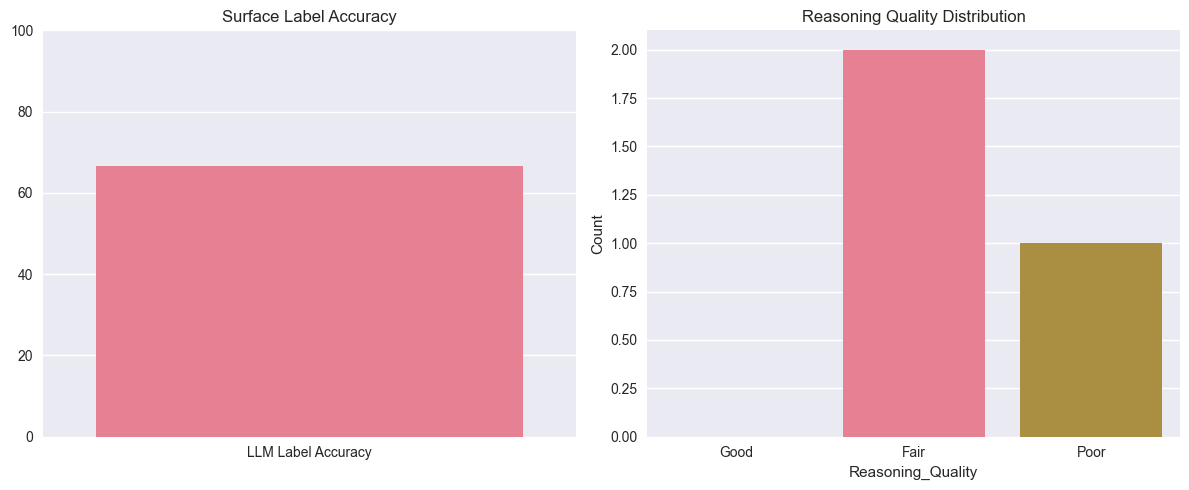

  Question  Label_Correct Reasoning_Quality
0       Q1           True              Fair
1       Q2           True              Fair
2       Q3          False              Poor

Overall Label Accuracy: 66.7%


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

q1_label_correct = True     
q1_reasoning_quality = "Fair"

q2_label_correct = True
q2_reasoning_quality = "Fair"

q3_label_correct = False
q3_reasoning_quality = "Poor"

# Build results DataFrame
results = pd.DataFrame({
    "Question": ["Q1", "Q2", "Q3"],
    "Label_Correct": [q1_label_correct, q2_label_correct, q3_label_correct],
    "Reasoning_Quality": [q1_reasoning_quality, q2_reasoning_quality, q3_reasoning_quality]
})

label_acc = results["Label_Correct"].mean() * 100

# Visualization
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(x=["LLM Label Accuracy"], y=[label_acc], ax=ax[0])
ax[0].set_ylim(0, 100)
ax[0].set_title("Surface Label Accuracy")

sns.countplot(
    x=results["Reasoning_Quality"], 
    ax=ax[1], 
    order=["Good", "Fair", "Poor"],
    hue=results["Reasoning_Quality"]   # Added for better visibility in newer seaborn
)

ax[1].set_title("Reasoning Quality Distribution")
ax[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

# Optional: Print a quick summary table
print(results)
print(f"\nOverall Label Accuracy: {label_acc:.1f}%")

## Takeaway

## Key Takeaways – Assemble Them All

- The LLM can generate **plausible high-level answers**, but its reasoning is shallow and generic.
- It rarely uses the actual geometry or specific assembly data provided by the dataset.
- It struggles with **spatial and physics-based reasoning** required for real 3D assembly tasks.
- Even when it gets the surface answer right, the underlying logic is not grounded.

**Main Gap**: General LLMs lack the ability to perform true geometric and physics-based assembly planning. They simulate reasoning rather than demonstrate understanding.